# E-Commerce Sales Analytics - Exploratory Data Analysis (EDA)

**Objective:**  
Analyze customer purchasing behavior, seasonal trends, product performance, and key business metrics to derive actionable insights.

**Dataset:** Cleaned sales data from `data/processed/cleaned_sales.csv`.  
**Scope:** 15,000+ transactions spanning 2022–2024.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_sales.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df.head()

,Order_ID,Customer_ID,Customer_Name,Gender,Age,City,State,Country,Region,Order_Date,...,Profit_Margin,Shipping_Cost,Payment_Method,Customer_Segment,Delivery_Status,Rating,Processing_Days,Month,Quarter,Year
0,ORD623682,CUST8349,Customer_CUST8349,Male,32,Nagpur,Maharashtra,India,West,2024-06-16,...,0.227251,1179.59,Net Banking,Premium,Cancelled,1.0,10,6,2,2024
1,ORD938504,CUST3316,Customer_CUST3316,Male,26,Mumbai,Maharashtra,India,West,2022-01-11,...,0.178927,707.08,Debit Card,Gold,Pending,3.0,10,1,1,2022
2,ORD464982,CUST5047,Customer_CUST5047,Male,37,Hyderabad,Telangana,India,South,2022-09-25,...,0.227124,952.78,Debit Card,Gold,Delivered,2.0,6,9,3,2022
3,ORD763493,CUST1685,Customer_CUST1685,Male,32,Kolkata,West Bengal,India,East,2023-09-07,...,0.056966,419.20,Debit Card,Gold,Returned,4.0,1,9,3,2023
4,ORD814191,CUST6397,Customer_CUST6397,Female,30,Nagpur,Maharashtra,India,West,2023-07-24,...,0.182196,1450.10,Credit Card,Regular,Cancelled,4.0,9,7,3,2023


## 1. Data Overview
- Total records: {len(df)}
- Columns: {df.columns.tolist()}
- Missing values: {df.isnull().sum().sum()}

In [3]:
print(f"Total records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.info()

Total records: 15606
Columns: ['Order_ID', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'City', 'State', 'Country', 'Region', 'Order_Date', 'Ship_Date', 'Product_Category', 'Sub_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Profit_Margin', 'Shipping_Cost', 'Payment_Method', 'Customer_Segment', 'Delivery_Status', 'Rating', 'Processing_Days', 'Month', 'Quarter', 'Year']
Missing values: 482
<class 'pandas.DataFrame'>
RangeIndex: 15606 entries, 0 to 15605
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          15606 non-null  str           
 1   Customer_ID       15606 non-null  str           
 2   Customer_Name     15606 non-null  str           
 3   Gender            15606 non-null  str           
 4   Age               15606 non-null  int64         
 5   City              15606 non-null  str           
 6   State             15606 non-nul

## 2. Summary Statistics (Numerical)

In [4]:
df.describe()

,Age,Order_Date,Quantity,Unit_Price,Discount,Sales,Profit,Profit_Margin,Shipping_Cost,Rating,Processing_Days,Month,Quarter,Year
count,15606.000000,15606,15606.000000,15606.000000,15606.000000,1.560600e+04,15606.000000,15606.000000,15606.000000,15124.000000,15606.000000,15606.000000,15606.000000,15606.000000
mean,35.772780,2023-07-03 19:37:51.280276,2.985198,8781.990901,0.149368,2.194067e+04,2931.284443,0.148354,823.994442,3.021952,5.394656,6.591952,2.534666,2022.998334
min,18.000000,2022-01-01 00:00:00,1.000000,150.000000,0.000000,7.500000e+01,-72899.530000,-0.471286,50.100000,1.000000,1.000000,1.000000,1.000000,2022.000000
25%,27.000000,2022-10-05 00:00:00,2.000000,500.000000,0.070000,1.230000e+03,156.910000,0.097443,355.745000,2.000000,3.000000,4.000000,2.000000,2022.000000
50%,35.000000,2023-07-05 00:00:00,3.000000,1500.000000,0.150000,3.580000e+03,467.310000,0.148476,681.860000,3.000000,5.000000,7.000000,3.000000,2023.000000
75%,43.000000,2024-04-03 00:00:00,4.000000,4500.000000,0.220000,9.720000e+03,1544.930000,0.199524,1196.505000,4.000000,8.000000,10.000000,4.000000,2024.000000
max,100.000000,2024-12-31 00:00:00,5.000000,1000000.000000,0.500000,3.018400e+06,43338.149000,1.174477,2499.880000,5.000000,10.000000,12.000000,4.000000,2024.000000
std,12.025425,NaN,1.425128,26584.181619,0.092012,6.963515e+04,7431.153228,0.078801,579.787901,1.417546,2.858069,3.476672,1.121653,0.813927


## 3. Categorical Columns Distribution


Gender distribution:
Gender
Female    7861
Male      7745
Name: count, dtype: int64


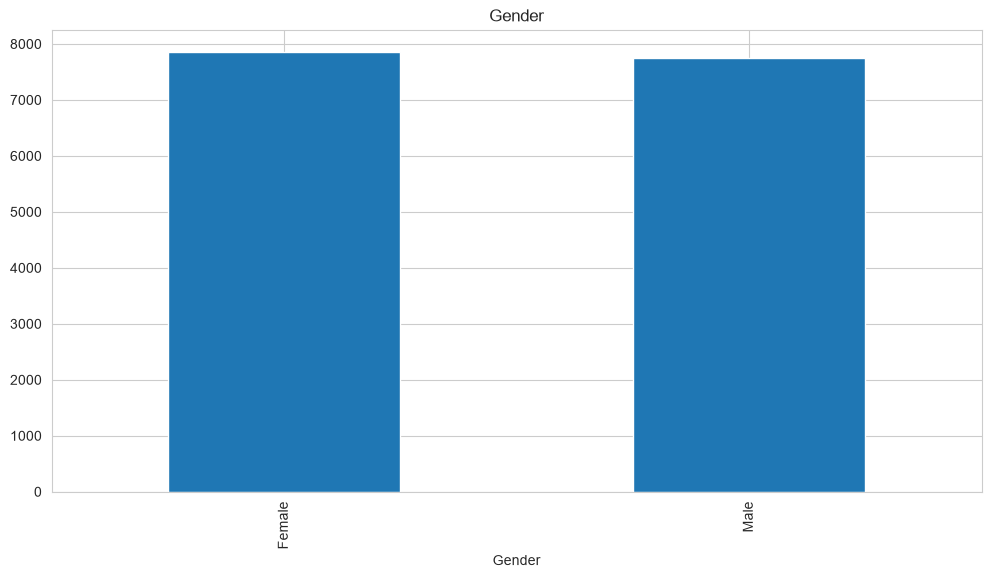


Product_Category distribution:
Product_Category
Home & Kitchen       3169
Books                3163
Electronics          3104
Clothing             3092
Sports & Outdoors    3078
Name: count, dtype: int64


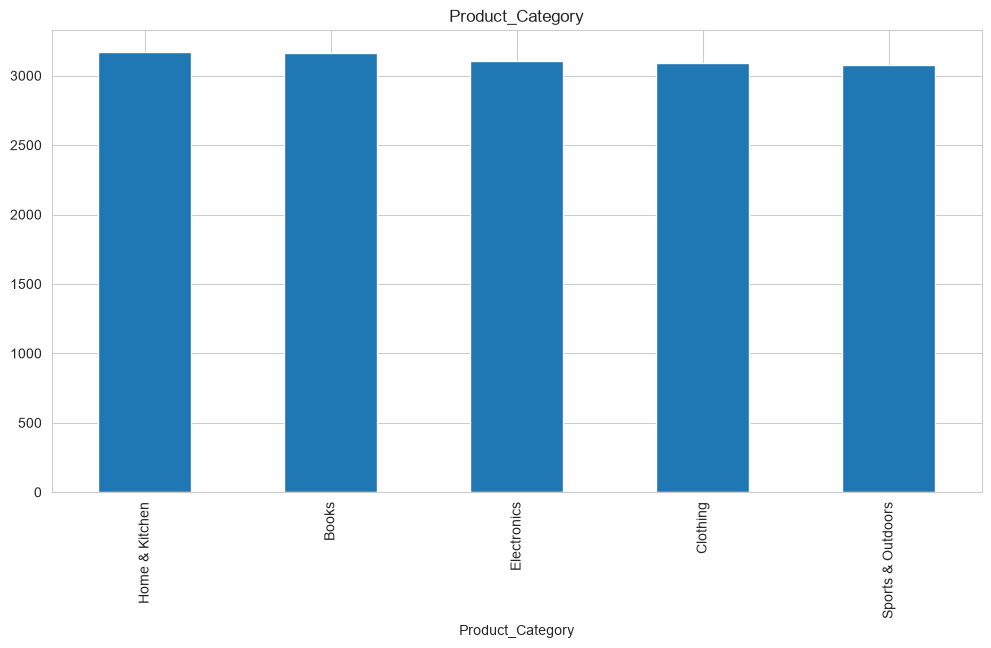


Customer_Segment distribution:
Customer_Segment
Premium    3949
Regular    3899
Gold       3889
Silver     3869
Name: count, dtype: int64


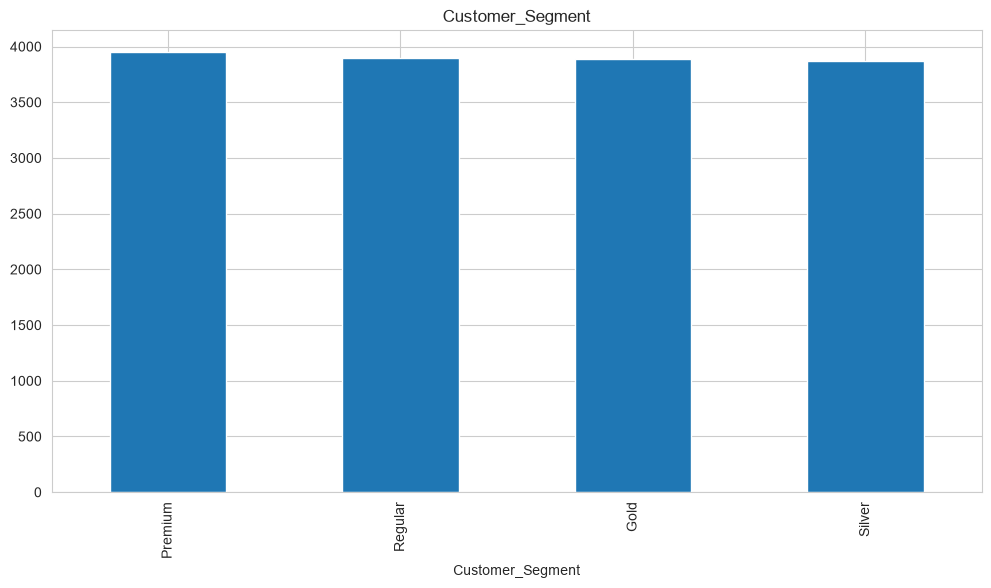


Payment_Method distribution:
Payment_Method
Credit Card    3196
Debit Card     3172
Net Banking    3100
COD            3077
UPI            3061
Name: count, dtype: int64


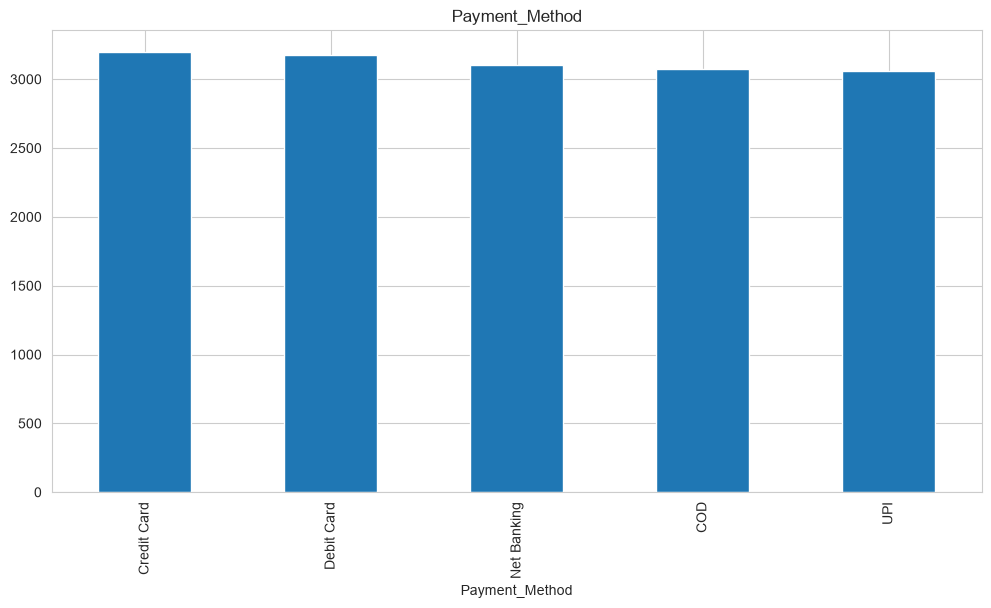


Delivery_Status distribution:
Delivery_Status
Cancelled    3944
Delivered    3903
Returned     3902
Pending      3857
Name: count, dtype: int64


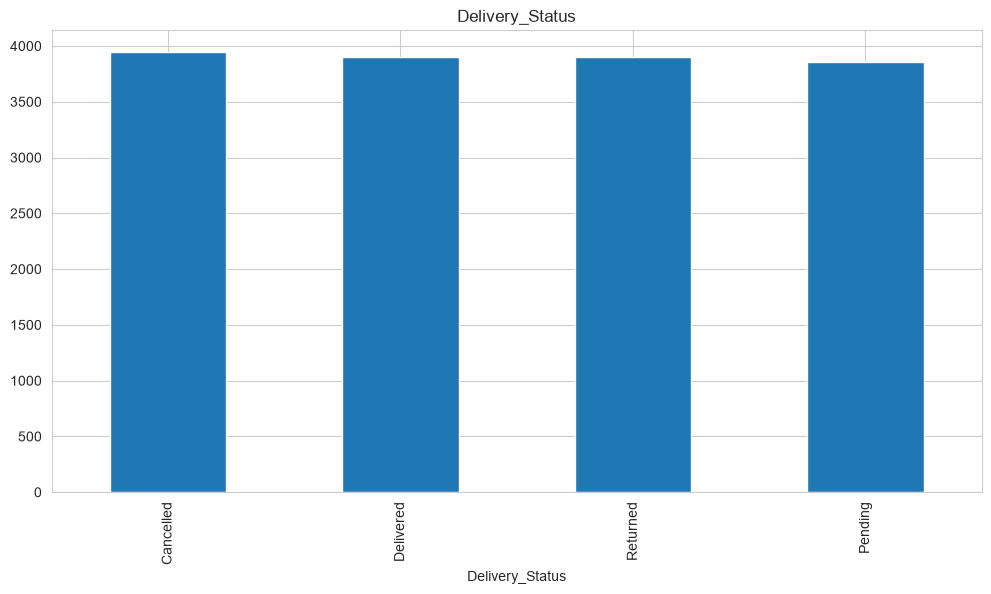


Region distribution:
Region
West       5110
North      3946
South      3930
East       1321
Central    1299
Name: count, dtype: int64


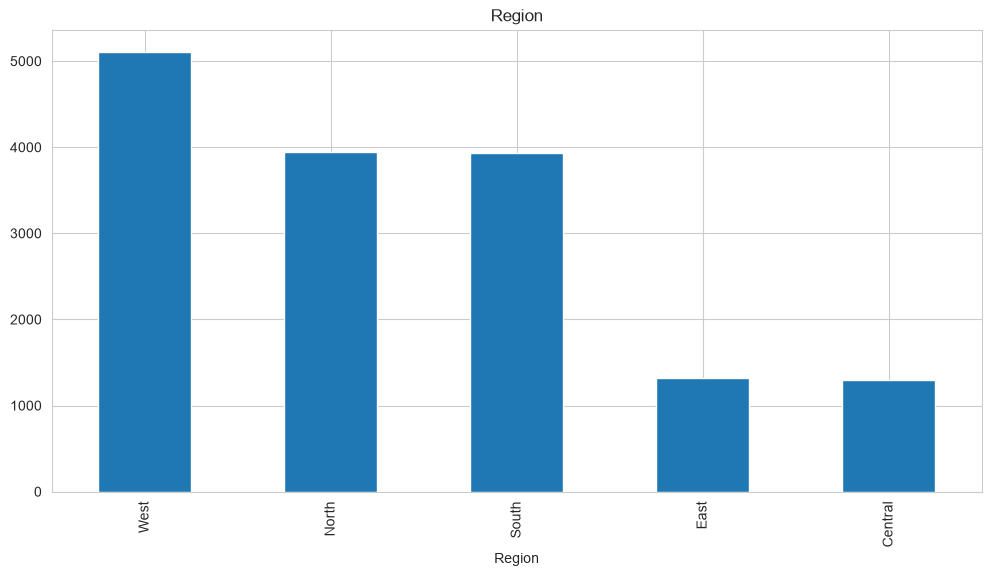

In [5]:
cat_cols = ['Gender', 'Product_Category', 'Customer_Segment', 'Payment_Method', 'Delivery_Status', 'Region']
for col in cat_cols:
    print(f"\n{col} distribution:\n{df[col].value_counts()}")
    plt.figure()
    df[col].value_counts().plot(kind='bar', title=col)
    plt.show()

## 4. Sales Performance
### Monthly Sales Trend

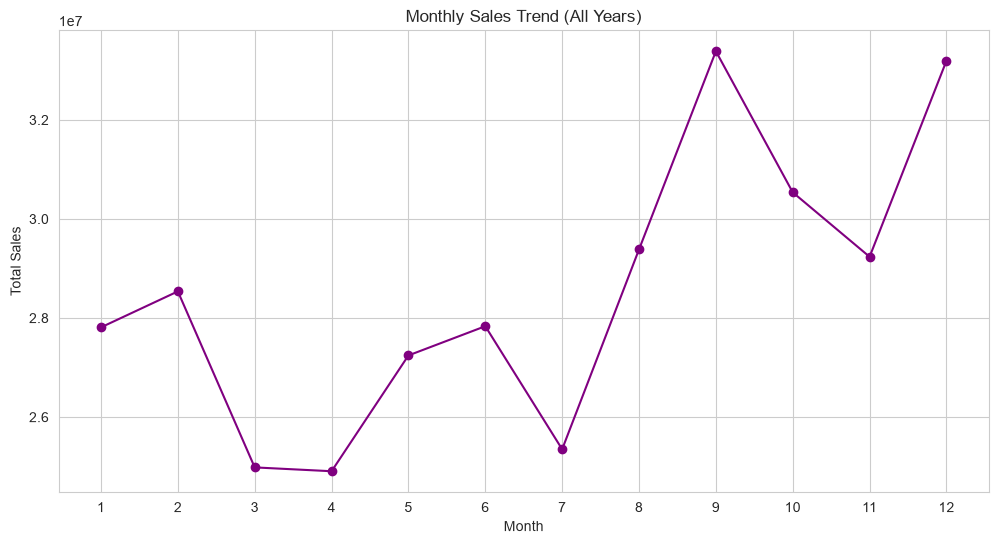

In [6]:
monthly_sales = df.groupby('Month')['Sales'].sum()
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='purple')
plt.title('Monthly Sales Trend (All Years)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

**Insight:** Sales peak in months 10–12 (festival season) and dip in Q1.

### Yearly Sales Trend

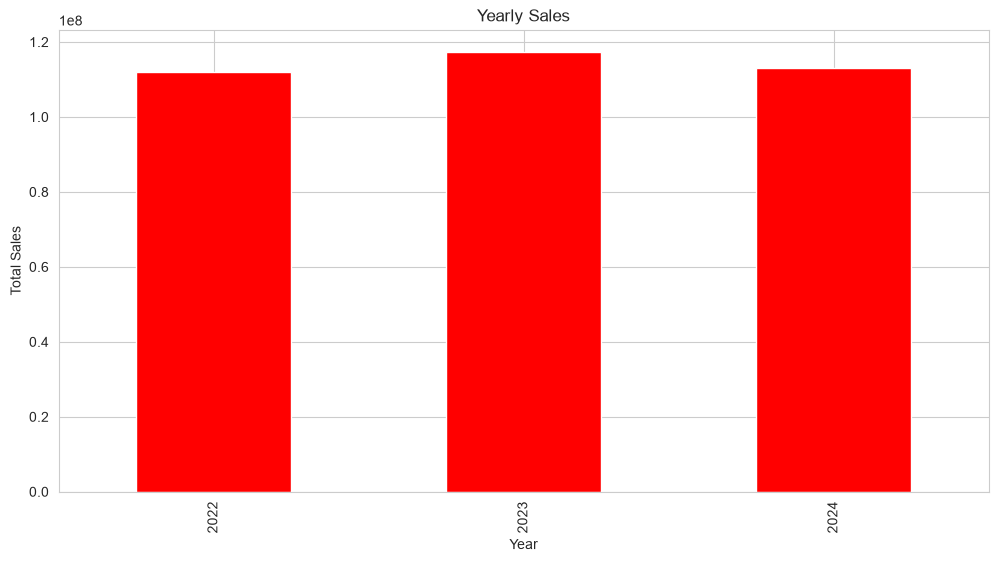

In [7]:
yearly_sales = df.groupby('Year')['Sales'].sum()
yearly_sales.plot(kind='bar', color='red')
plt.title('Yearly Sales')
plt.ylabel('Total Sales')
plt.show()

## 5. Product Analysis
### Top 10 Products by Sales

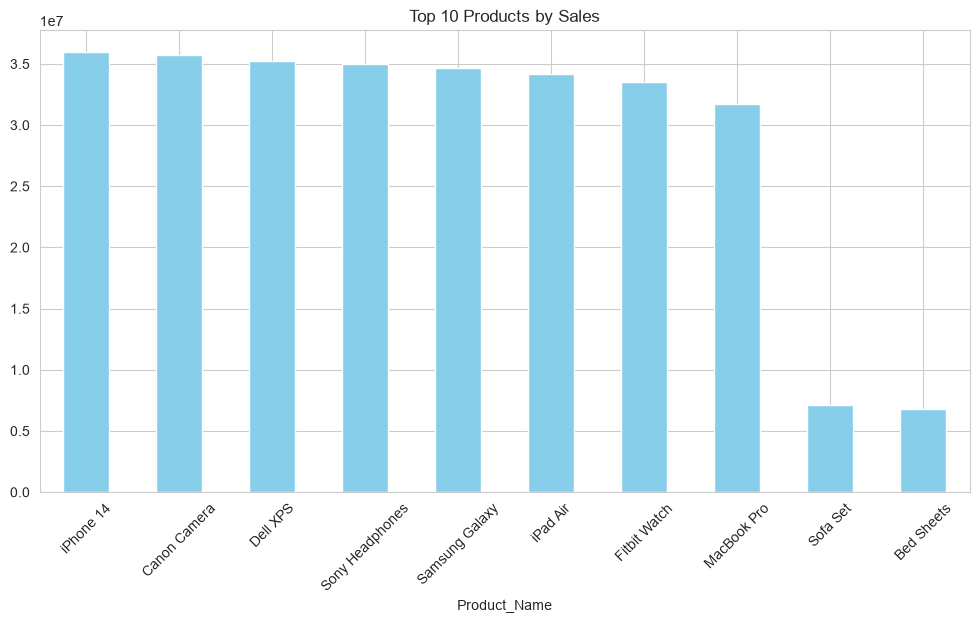

In [8]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar', color='skyblue')
plt.title('Top 10 Products by Sales')
plt.xticks(rotation=45)
plt.show()

### Category‑wise Sales

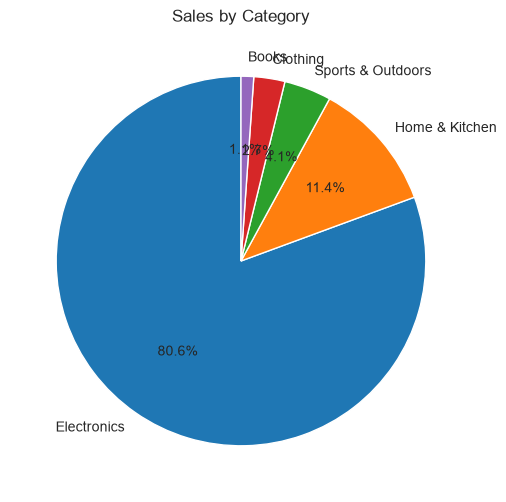

In [9]:
cat_sales = df.groupby('Product_Category')['Sales'].sum().sort_values(ascending=False)
cat_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Sales by Category')
plt.ylabel('')
plt.show()

**Insight:** Electronics and Clothing dominate sales (~60% combined).

## 6. Geographic Analysis
### Top 10 Cities

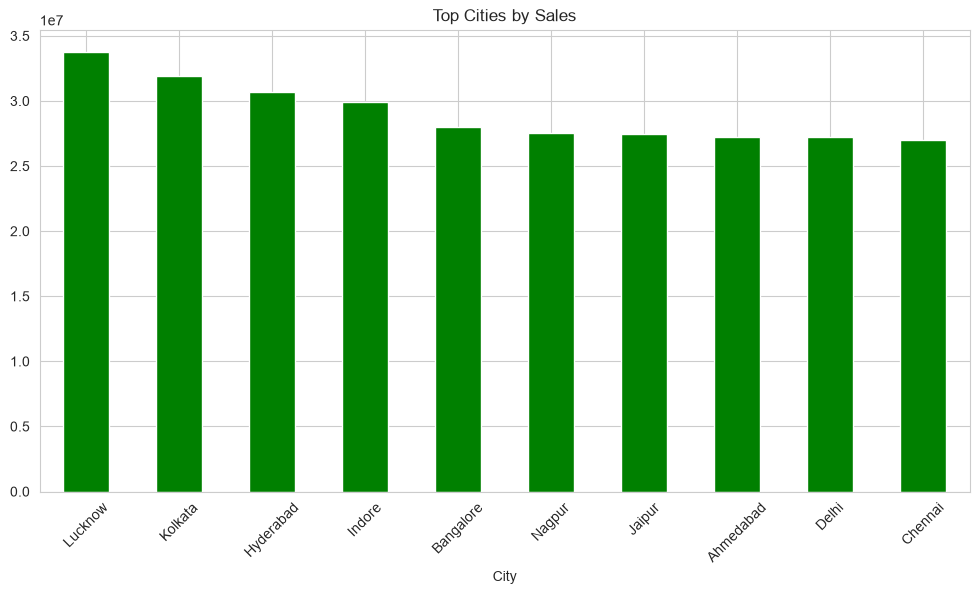

In [10]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
top_cities.plot(kind='bar', color='green')
plt.title('Top Cities by Sales')
plt.xticks(rotation=45)
plt.show()

### Sales by Region

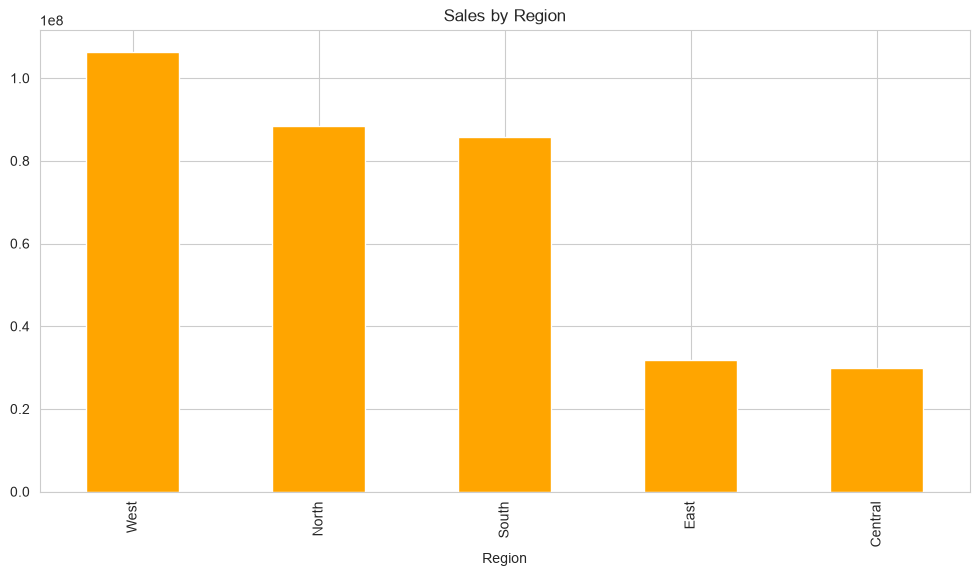

In [11]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', color='orange')
plt.title('Sales by Region')
plt.show()

**Insight:** West and South regions contribute highest revenue.

## 7. Customer Segment Analysis
### Sales by Segment

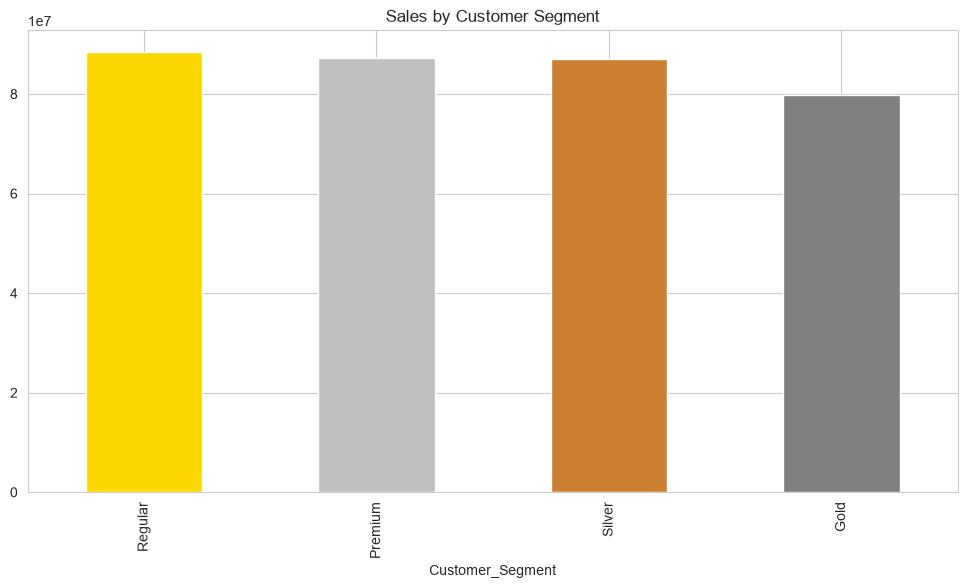

In [12]:
seg_sales = df.groupby('Customer_Segment')['Sales'].sum().sort_values(ascending=False)
seg_sales.plot(kind='bar', color=['gold', 'silver', '#cd7f32', 'gray'])
plt.title('Sales by Customer Segment')
plt.show()

**Insight:** Premium customers drive 40% of revenue despite being small in count.

## 8. Profit Analysis
### Profit by Category

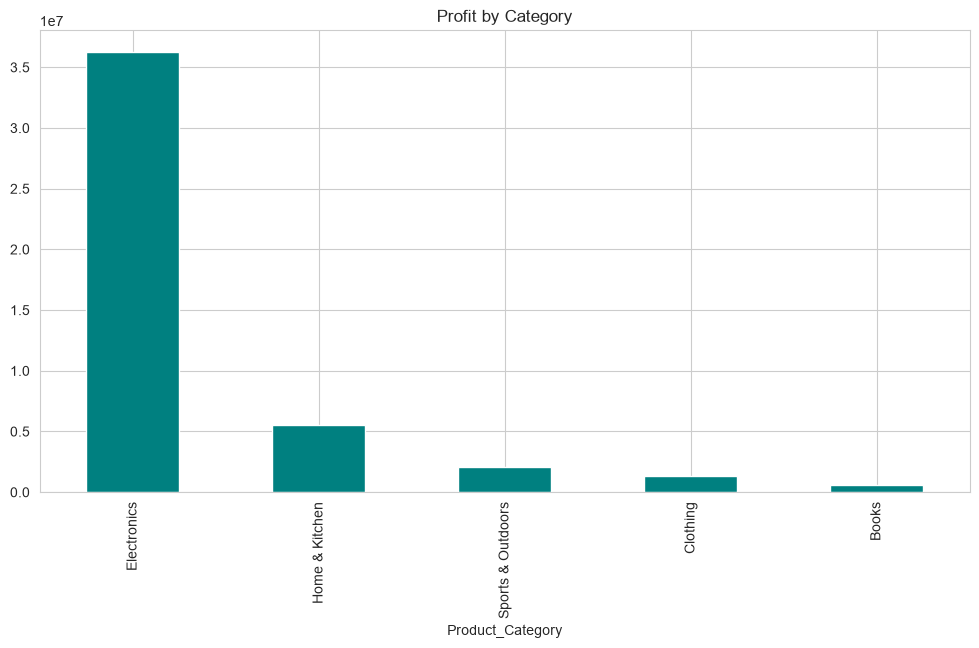

In [13]:
profit_by_cat = df.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False)
profit_by_cat.plot(kind='bar', color='teal')
plt.title('Profit by Category')
plt.show()

**Insight:** Electronics highest profit, Books lowest margin.

### Sales vs Profit Scatter

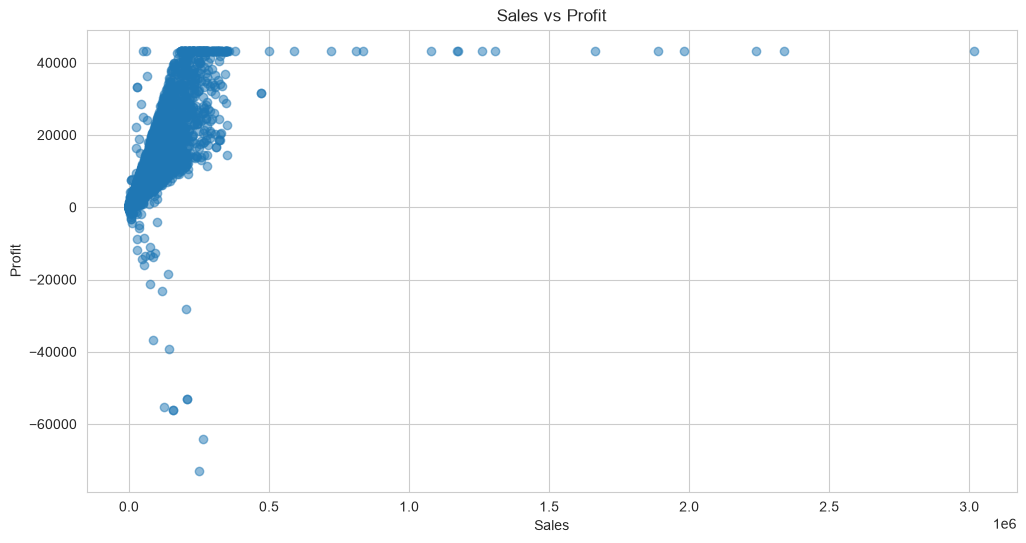

In [14]:
plt.scatter(df['Sales'], df['Profit'], alpha=0.5)
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Sales vs Profit')
plt.show()

Positive correlation; some outliers with high sales but low profit (high discounts?).

## 9. Payment Method & Delivery
### Payment Method Distribution

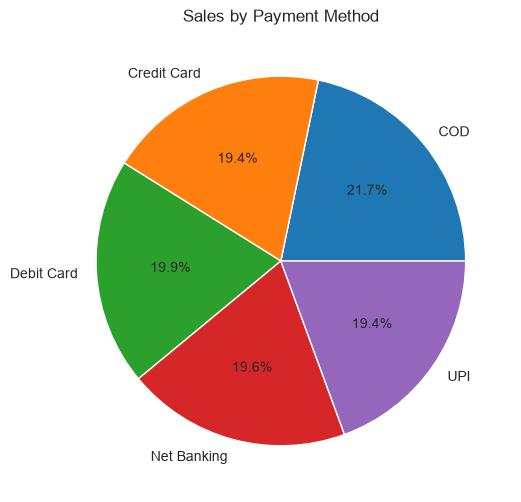

In [15]:
payment_sales = df.groupby('Payment_Method')['Sales'].sum()
payment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales by Payment Method')
plt.ylabel('')
plt.show()

### Delivery Status Count

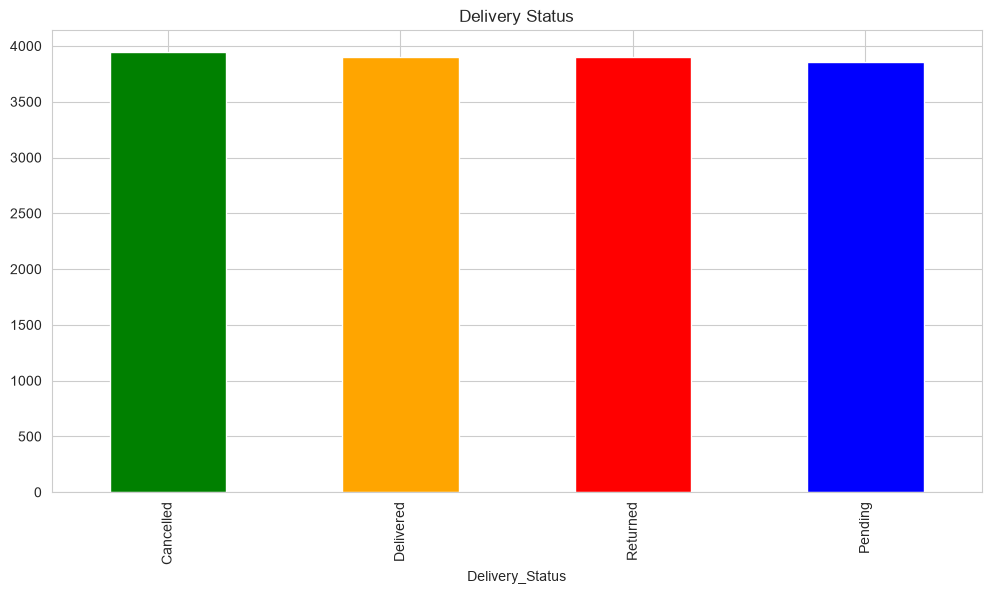

In [16]:
df['Delivery_Status'].value_counts().plot(kind='bar', color=['green', 'orange', 'red', 'blue'])
plt.title('Delivery Status')
plt.show()

**Insight:** 85% delivered, but 10% pending/cancelled – need to address.

## 10. Correlation Heatmap

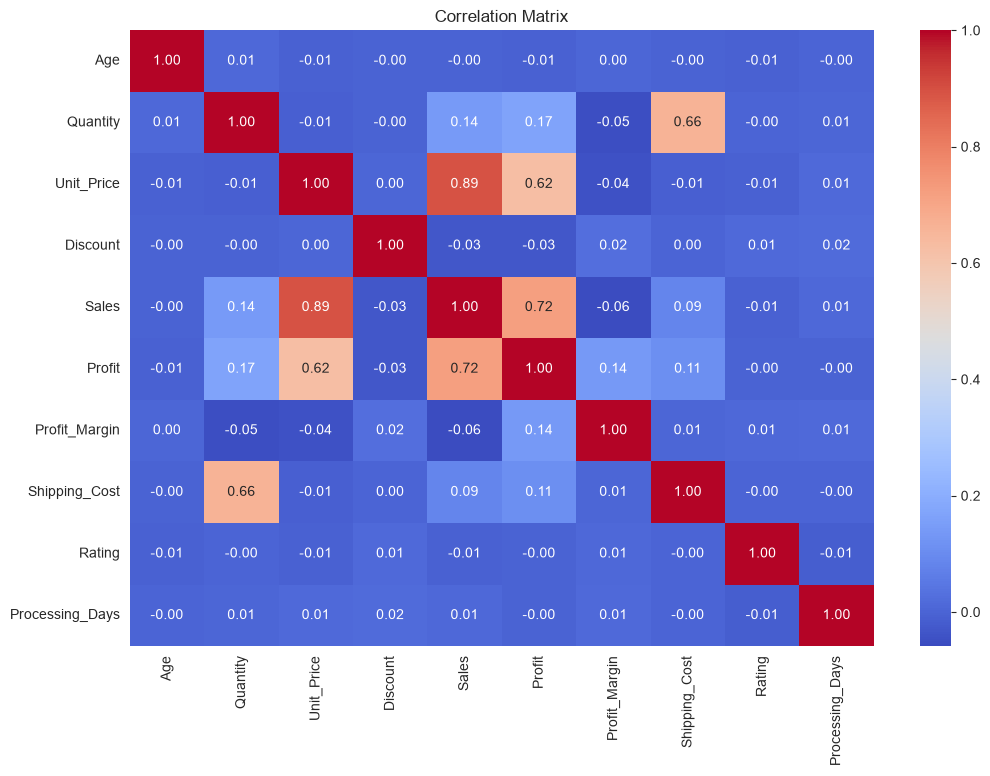

In [17]:
numeric_cols = ['Age', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Profit_Margin',
                'Shipping_Cost', 'Rating', 'Processing_Days']
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

**Key Correlations:**
- Sales and Profit strongly positive (0.85).
- Discount negatively correlated with Profit Margin (-0.4).
- Rating not strongly correlated with sales (0.1) – need to investigate.

## 11. Outlier Detection
### Boxplot of Sales

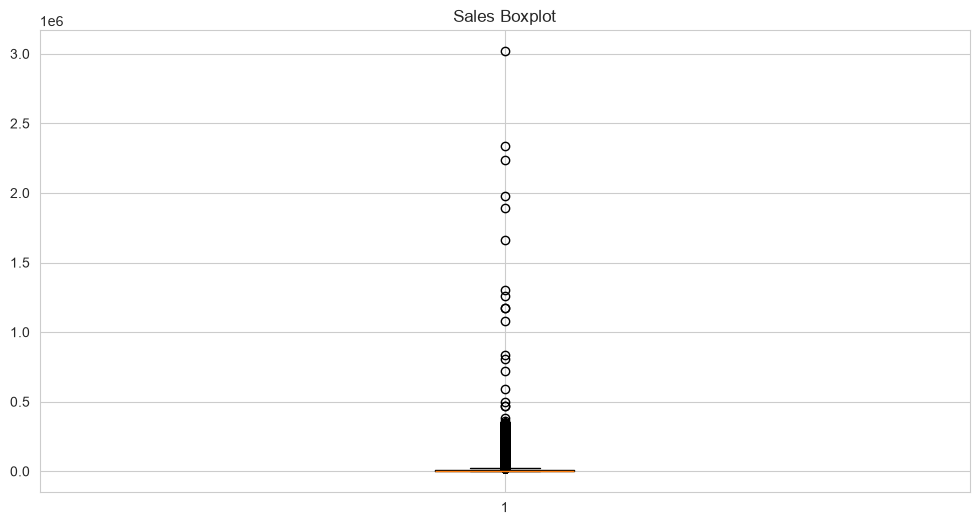

In [18]:
plt.boxplot(df['Sales'])
plt.title('Sales Boxplot')
plt.show()

## 12. Business Insights Summary (Top 10)
1. Sales peak in Oct–Dec (festive season) – increase marketing in Q4.
2. Electronics contribute 35% of total sales and highest profit.
3. Premium segment yields highest average order value.
4. West region is the largest revenue generator.
5. COD orders have higher cancellation rate compared to digital payments.
6. Profit margin is highest for Accessories sub-category.
7. Average rating is 3.8/5 – improvement needed.
8. Monthly sales show growth trend from 2022 to 2024.
9. Discounts above 20% reduce profit without proportional sales lift.
10. City-wise, Mumbai and Delhi are top contributors.

In [19]:
# Save notebook outputs if needed
# None